各工作站產出率 TH_i = [0.6        0.375      0.5        0.5        0.41666667]
瓶頸站產出率 rb = 0.375
最小生產週期時間 T0 = 41.0
臨界在製品 W0 = 15.375

WIP	TH		CT
1	0.0244		41.0000
2	0.0488		41.0000
3	0.0732		41.0000
4	0.0976		41.0000
5	0.1220		41.0000
6	0.1463		41.0000
7	0.1707		41.0000
8	0.1951		41.0000
9	0.2195		41.0000
10	0.2439		41.0000
11	0.2683		41.0000
12	0.2927		41.0000
13	0.3171		41.0000
14	0.3415		41.0000
15	0.3659		41.0000
16	0.3750		42.6667
17	0.3750		45.3333
18	0.3750		48.0000
19	0.3750		50.6667
20	0.3750		53.3333
21	0.3750		56.0000
22	0.3750		58.6667
23	0.3750		61.3333
24	0.3750		64.0000
25	0.3750		66.6667
26	0.3750		69.3333
27	0.3750		72.0000
28	0.3750		74.6667
29	0.3750		77.3333
30	0.3750		80.0000
31	0.3750		82.6667
32	0.3750		85.3333
33	0.3750		88.0000
34	0.3750		90.6667
35	0.3750		93.3333
36	0.3750		96.0000
37	0.3750		98.6667
38	0.3750		101.3333
39	0.3750		104.0000
40	0.3750		106.6667


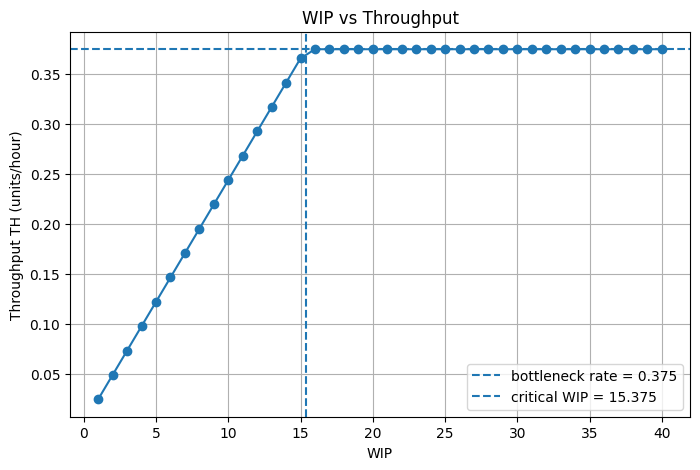

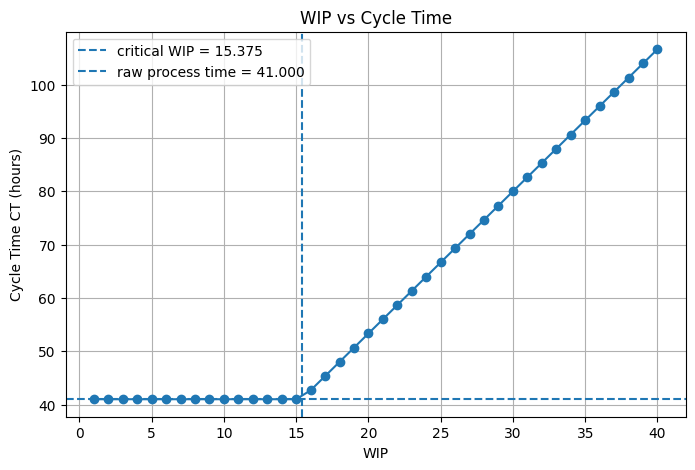

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 基本參數
# -----------------------------
station_ids = [1, 2, 3, 4, 5]
m = np.array([3, 3, 6, 2, 5], dtype=float)      # 平行等效機台數
t = np.array([5, 8, 12, 4, 12], dtype=float)    # 加工時間（小時）

# 各工作站產能
TH_i = m / t

# 瓶頸產能
rb = np.min(TH_i)

# 原始加工時間
T0 = np.sum(t)

# 臨界在製品
W0 = rb * T0

print("各工作站產出率 TH_i =", TH_i)
print("瓶頸站產出率 rb =", rb)
print("最小生產週期時間 T0 =", T0)
print("臨界在製品 W0 =", W0)

# -----------------------------
# 模擬不同 WIP 下的最佳績效
# -----------------------------
WIP_values = np.arange(1, 41, 1)   # WIP 從 1 到 40
TH_values = []
CT_values = []

for WIP in WIP_values:
    TH = min(rb, WIP / T0)
    CT = WIP / TH
    TH_values.append(TH)
    CT_values.append(CT)

# -----------------------------
# 顯示數值表
# -----------------------------
print("\nWIP\tTH\t\tCT")
for w, th, ct in zip(WIP_values, TH_values, CT_values):
    print(f"{w}\t{th:.4f}\t\t{ct:.4f}")

# -----------------------------
# 圖 1：WIP vs TH
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(WIP_values, TH_values, marker='o')
plt.axhline(rb, linestyle='--', label=f'bottleneck rate = {rb:.3f}')
plt.axvline(W0, linestyle='--', label=f'critical WIP = {W0:.3f}')
plt.xlabel('WIP')
plt.ylabel('Throughput TH (units/hour)')
plt.title('WIP vs Throughput')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 圖 2：WIP vs CT
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(WIP_values, CT_values, marker='o')
plt.axvline(W0, linestyle='--', label=f'critical WIP = {W0:.3f}')
plt.axhline(T0, linestyle='--', label=f'raw process time = {T0:.3f}')
plt.xlabel('WIP')
plt.ylabel('Cycle Time CT (hours)')
plt.title('WIP vs Cycle Time')
plt.legend()
plt.grid(True)
plt.show()